In [6]:
# DATA IMPORT AND EXPLORATION
## import breast cancer tissue dataset from sklearn
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target

import pandas as pd 

## convert raw data into dataframe
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

## quick data exploration
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "median" : df.median(numeric_only=True),
    "mean": df.mean(numeric_only=True),
    "std": df.std(numeric_only=True),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True)
})
print(summary)
print("class balance: " , df['target'].value_counts() )  # class balance


                           dtype  missing      median        mean         std  \
mean radius              float64        0   13.370000   14.127292    3.524049   
mean texture             float64        0   18.840000   19.289649    4.301036   
mean perimeter           float64        0   86.240000   91.969033   24.298981   
mean area                float64        0  551.100000  654.889104  351.914129   
mean smoothness          float64        0    0.095870    0.096360    0.014064   
mean compactness         float64        0    0.092630    0.104341    0.052813   
mean concavity           float64        0    0.061540    0.088799    0.079720   
mean concave points      float64        0    0.033500    0.048919    0.038803   
mean symmetry            float64        0    0.179200    0.181162    0.027414   
mean fractal dimension   float64        0    0.061540    0.062798    0.007060   
radius error             float64        0    0.324200    0.405172    0.277313   
texture error            flo

Comments : No missing values, different value ranges accross the different features (some range around 600, others around 0.01), some have high variability (see sd).
Class balance : slightly imbalanced but still acceptable (no balancing methods needed here)

In [7]:
# MODEL IMPORT AND PREPARATION 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)     # max iter set to 5000 to ensure convergence 
    ),

    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier()
    ),

    "Linear SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="linear")
    ),

    "RBF SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf")
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

Highly correlated features (|r| ≥ 0.90):
               Feature 1             Feature 2  Correlation
1            mean radius        mean perimeter     0.997815
391         worst radius       worst perimeter     0.993719
2            mean radius             mean area     0.986740
57        mean perimeter             mean area     0.985960
392         worst radius            worst area     0.983107
407      worst perimeter            worst area     0.976665
246         radius error       perimeter error     0.974705
76        mean perimeter       worst perimeter     0.970006
74        mean perimeter          worst radius     0.969332
19           mean radius          worst radius     0.969256
21           mean radius       worst perimeter     0.964439
100            mean area          worst radius     0.960725
103            mean area            worst area     0.958177
102            mean area       worst perimeter     0.956714
247         radius error            area error     0.951558

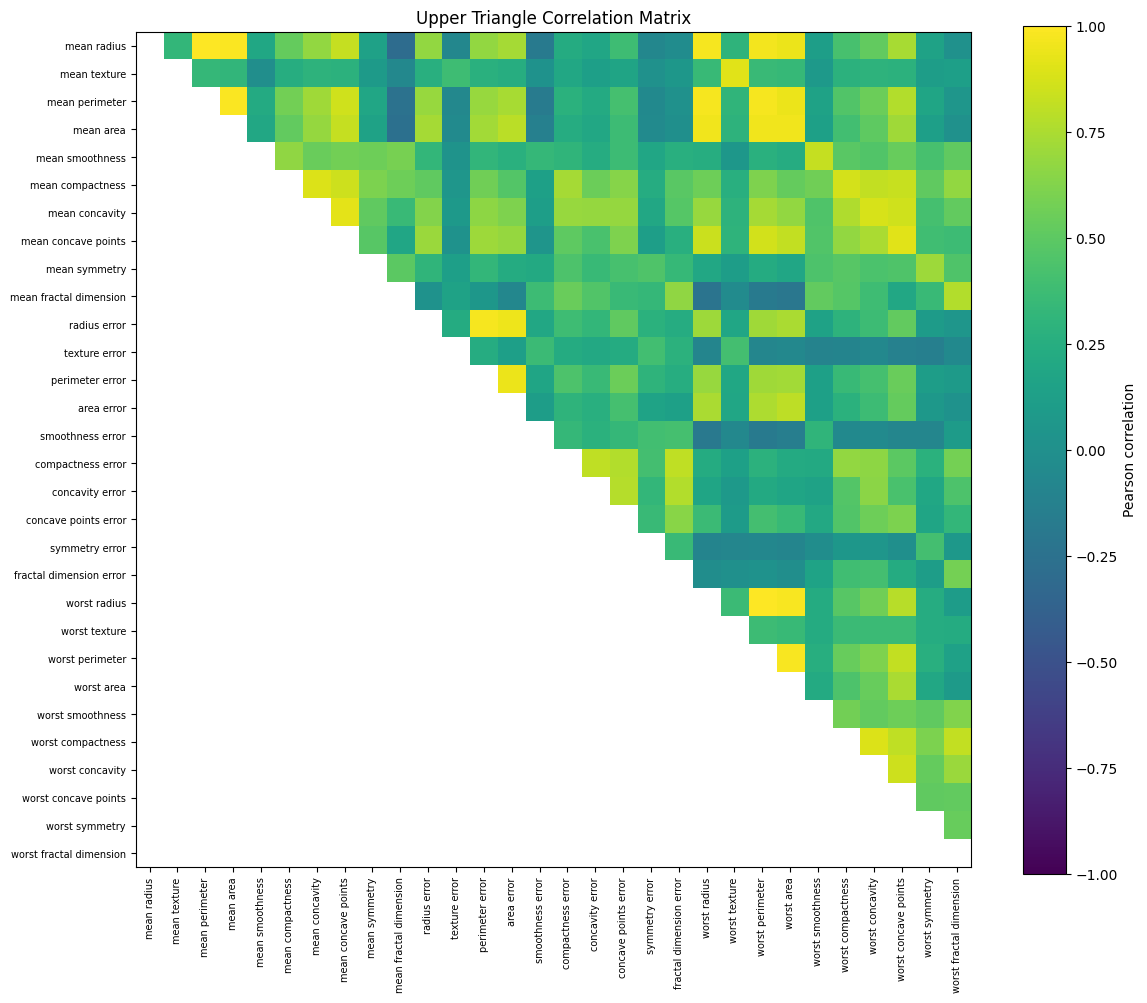

In [12]:
# DATA SPLITTING AND CORRELATION ANALYSIS
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Features
X = df.drop(columns="target")

# Recode outcome: 1 = malignant,  0 = benign
y = (df["target"] == 0).astype(int)

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Correlation analysis - training data only
import numpy as np
corr_matrix = X_train.corr()

# Keep only upper triangle to avoid duplicate pairs
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Extract highly correlated feature pairs
high_corr = upper.stack().reset_index()
high_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr = high_corr[
    high_corr["Correlation"].abs() >= 0.9
].sort_values(
    "Correlation",
    key=lambda x: x.abs(),
    ascending=False
)

print("Highly correlated features (|r| ≥ 0.90):")
print(high_corr)

# Plot visualization of the correlation matrix
import matplotlib.pyplot as plt

mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))

plt.imshow(
    np.ma.masked_where(mask, corr_matrix),
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Pearson correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    fontsize=7
)

plt.title("Upper Triangle Correlation Matrix")
plt.tight_layout()
plt.show()

drop_cols = [
    "mean perimeter", "mean area",
    "perimeter error", "area error",
    "worst perimeter", "worst area",
    "mean concavity", "worst concave points",
    "mean texture"
]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

Why to check correlation ? If many predictors are highly correlated, interpretation can be misleading because several variables may appear informative while actually carrying largely the same underlying information.

Interpretation : Several groups of strongly correlated predictors, particularly size-related variables such as radius, perimeter and area, indicating redundancy among features. I manually removed the 9 least informative/interpretable ones (e.g. perimeter and area are mathematically derived from radius (same shape info), so they add nothing new).

Comment : correlation analysis run on training data only to avoid data leakage

In [13]:
# MODEL COMPARISON USING CROSS-VALIDATION
results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "roc_auc"]
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "ROC-AUC SD": scores["test_roc_auc"].std()
    })

results = pd.DataFrame(results)
results = results.sort_values("ROC-AUC", ascending=False)

print(results)

                 Model  Accuracy  Accuracy SD   ROC-AUC  ROC-AUC SD
0  Logistic Regression  0.969227     0.029891  0.994791    0.009162
2           Linear SVM  0.969227     0.024437  0.993538    0.008881
3              RBF SVM  0.964734     0.034579  0.993132    0.009839
5    Gradient Boosting  0.969179     0.035587  0.991857    0.014271
4        Random Forest  0.956039     0.039163  0.989007    0.013686
1                  KNN  0.962560     0.038416  0.985678    0.023212


Interpretation : all models have a high accuracy / ROC-AUC. Logistic regression and RBF SVM have the best performance. I decided to favor Logistic Regression because it is easier to interpret and directly provides cancer probabilities.

Reminder :    
Accuracy : proportion of all predictions that are correct. If we pick 1 patient randomly, the model has x % chances of classifying her correctly.    
ROC-AUC : describes how well the model ranks one class above the other. model will rank a cancer tissue higher than a control in x % of cases.    
Interest of looking at both ? Accuracy looks at performance at ONE threshold (convention=0.5), ROC looks at quality of separation over ALL thresholds

In [14]:
# PARAMETER TUNING FOR LOGREG
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, confusion_matrix

# REGULARIZATION COMPARISON: L2 vs L1 vs ELASTIC NET
from sklearn.model_selection import GridSearchCV
pd.set_option("display.max_colwidth", None)

regularizations = {
    "L2": {
        "model": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                penalty="l2",
                solver="saga",
                max_iter=10000,
                random_state=42
            )
        ),
        "params": {
            "logisticregression__C": [0.01, 0.1, 1, 10, 100]
        }
    },

    "L1": {
        "model": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                penalty="l1",
                solver="saga",
                max_iter=10000,
                random_state=42
            )
        ),
        "params": {
            "logisticregression__C": [0.01, 0.1, 1, 10, 100]
        }
    },

    "Elastic Net": {
        "model": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=10000,
                random_state=42
            )
        ),
        "params": {
            "logisticregression__C": [0.01, 0.1, 1, 10, 100],
            "logisticregression__l1_ratio": [0.1, 0.5, 0.9]
        }
    }
}

reg_results = []

for name, config in regularizations.items():

    grid = GridSearchCV(
        config["model"],
        config["params"],
        cv=cv,
        scoring="roc_auc"
    )

    grid.fit(X_train, y_train)

    logreg = grid.best_estimator_.named_steps["logisticregression"]
    n_features = (logreg.coef_[0] != 0).sum()

    reg_results.append({
        "Regularization": name,
        "Best ROC-AUC": grid.best_score_,
        "Features retained": n_features,
        "Best parameters": grid.best_params_
    })

reg_results = pd.DataFrame(reg_results)
print(reg_results)

  Regularization  Best ROC-AUC  Features retained  \
0             L2      0.994791                 21   
1             L1      0.994806                 12   
2    Elastic Net      0.995212                 17   

                                                     Best parameters  
0                                       {'logisticregression__C': 1}  
1                                       {'logisticregression__C': 1}  
2  {'logisticregression__C': 1, 'logisticregression__l1_ratio': 0.5}  


Interpretation : Predictor number reduction with L1 did not decrease model performance (ROC-AUC) while simplifying the model (12 predictors kept). Elastic did not bring any benefit.
L1 Logreg is the simplest model, so we will use it for next steps

Reminder : C is inverse regularization strength.
How strong the model restricts coefficients with low C = strongly restricted and high C less restricted (C=1 → default)

In [28]:
# THRESHOLD OPTIMIZATION WITH L1 LOGREG

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, confusion_matrix
import numpy as np

# Retrieve best C found for L1
best_C_l1 = reg_results.loc[
    reg_results["Regularization"] == "L1",
    "Best parameters"
].iloc[0]["logisticregression__C"]

# Final L1 model
best_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty="l1",
        solver="saga",
        C=best_C_l1,
        max_iter=10000,
        random_state=42
    )
)

# Out-of-fold probabilities on training data
y_prob_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

# ROC curve from out-of-fold predictions (training CV)
fpr, tpr, thresholds = roc_curve(y_train, y_prob_cv)

# YOUDEN THRESHOLD
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print(f"Youden threshold = {best_threshold:.3f}")
print(f"Sensitivity: {tpr[best_idx]:.3f}")
print(f"Specificity: {1 - fpr[best_idx]:.3f}")

# MINIMUM-SENSITIVITY THRESHOLD (>= 0.98)
target_sensitivity = 0.98
valid_idx = np.where(tpr >= target_sensitivity)[0]
best_idx_98 = valid_idx[np.argmax(thresholds[valid_idx])]
threshold_98 = thresholds[best_idx_98]

print(f"\nThreshold for sensitivity >= {target_sensitivity}: {threshold_98:.3f}")
print(f"Sensitivity: {tpr[best_idx_98]:.3f}")
print(f"Specificity: {1 - fpr[best_idx_98]:.3f}")


Youden threshold = 0.412
Sensitivity: 0.976
Specificity: 0.986

Threshold for sensitivity >= 0.98: 0.188
Sensitivity: 0.982
Specificity: 0.947


Interpretation : high drop of specificity when sensitivity is set above 98%. Since sensitivity for Youden and set thresholds is nearly similar, better taking Youden to get the better specificity.

Remark : Sensitivity is very important in oncology field because it is much more important not missing cancer patients than not missing controls.

Threshold: 0.412
Accuracy: 0.974
ROC-AUC: 0.996
Sensitivity: 0.952
Specificity: 0.986


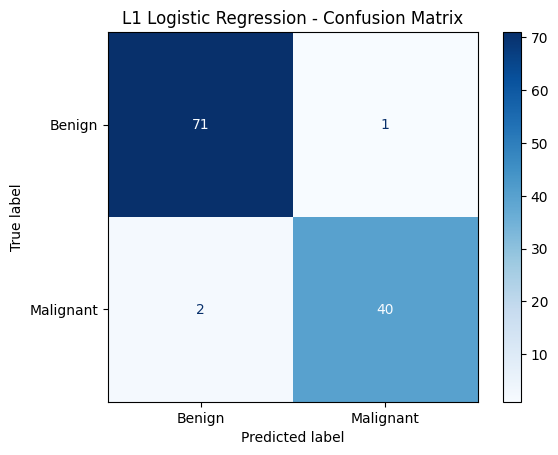

In [29]:
# FINAL L1 LOGISTIC REGRESSION EVALUATION WITH TEST SET
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Fit selected L1 model on all training data
best_model.fit(X_train, y_train)

# Predicted probabilities on untouched test set
y_prob = best_model.predict_proba(X_test)[:, 1]

# Apply Youden threshold previously determined from training CV predictions
y_pred = (y_prob >= best_threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Threshold: {best_threshold:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")


# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Benign", "Malignant"],
    cmap="Blues",
    values_format="d"
)

plt.title("L1 Logistic Regression - Confusion Matrix")
plt.show()

Interpretation : Real performance evaluated on test datset gave a sensitivy of 95,2%, specificity of 98,6% and ROC of 99.6%. 3 missclassifications : 2 malignant tissues classified as benign, 1 benign tissue classified as malignant.

In [ ]:
# COEFFICIENTS AND SELECTED FEATURES ANALYSIS 

logreg = best_model.named_steps["logisticregression"]

feature_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logreg.coef_[0]
})

feature_table["Abs_Coefficient"] = feature_table["Coefficient"].abs()

feature_table = feature_table[feature_table["Coefficient"] != 0]

feature_table = feature_table.sort_values("Abs_Coefficient", ascending=False)

print(f"Features retained by L1: {len(feature_table)}")
print(feature_table)

Features retained by L1: 12
                    Feature  Coefficient  Abs_Coefficient
14             worst radius     3.339871         3.339871
6              radius error     2.655579         2.655579
15            worst texture     2.123150         2.123150
3       mean concave points     2.003564         2.003564
18          worst concavity     1.174512         1.174512
9         compactness error    -1.002541         1.002541
7             texture error    -0.747518         0.747518
19           worst symmetry     0.649764         0.649764
11     concave points error     0.325942         0.325942
13  fractal dimension error    -0.311966         0.311966
16         worst smoothness     0.285661         0.285661
8          smoothness error     0.283160         0.283160


Interpretation : the dominant signal is size (worst radius, radius error) and shape/texture irregularity (worst texture, mean concave points, worst concavity) -> consistent with the known biology that malignant tumors tend to be larger and more irregularly shaped than benign ones. 

In [35]:
# FEATURE SELECTION STABILITY VIA BOOTSTRAP
from sklearn.utils import resample

n_bootstraps = 200
selection_counts = np.zeros(X_train.shape[1])

for i in range(n_bootstraps):
    X_bs, y_bs = resample(
        X_train, y_train,
        stratify=y_train,
        random_state=i
    )

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            penalty="l1",
            solver="saga",
            C=best_C_l1,
            max_iter=10000,
            random_state=42
        )
    )
    model.fit(X_bs, y_bs)

    coefs = model.named_steps["logisticregression"].coef_[0]
    selection_counts += (coefs != 0)

stability = pd.DataFrame({
    "Feature": X_train.columns,
    "Selection frequency (%)": 100 * selection_counts / n_bootstraps
}).sort_values("Selection frequency (%)", ascending=False)

print(stability)

                    Feature  Selection frequency (%)
15            worst texture                    100.0
18          worst concavity                    100.0
14             worst radius                    100.0
3       mean concave points                     99.5
19           worst symmetry                     97.5
6              radius error                     96.0
7             texture error                     87.0
13  fractal dimension error                     84.0
9         compactness error                     77.0
16         worst smoothness                     74.5
8          smoothness error                     61.5
11     concave points error                     59.5
12           symmetry error                     38.0
4             mean symmetry                     33.0
5    mean fractal dimension                     28.5
1           mean smoothness                     28.5
0               mean radius                     24.5
2          mean compactness                   

Interpretation : Most L1-selected features are stable across resampling. 8/12 show ≥74% selection frequency, confirming they aren't artifacts of one particular train/test split. 2 features (concave points error, smoothness error, ~60%) are weakly supported.     

Remark : "worst" (extreme-value) statistics are consistently more stable than their "mean" counterparts for the same measurement (e.g. worst radius 100% vs mean radius 24.5%; worst symmetry 97.5% vs mean symmetry 33%), suggesting the most atypical cells in a sample have more diagnostic signal than the average cell.

GENERAL CONCLUSION : From this breast tissue dataset, I selected a logistic regression model with L1 regularization to best separate malignant from benign tissue. It achieves excellent performance (ROC-AUC 0.996, accuracy 97.4%) with a good sensitivity/specificity compromise (95.2% / 98.6%), and identifies a stable, interpretable set of predictors